# E-Commerce Product Delivery Prediction

## 1. Project Introduction

### Project Overview

This project focuses on predicting whether an e-commerce product will reach the customer on time.

The dataset contains information related to warehouse location, shipment mode, customer interactions, customer ratings, product cost, previous purchases, product importance, gender, discount offered, and product weight.

The objective is to develop machine learning classification models that can predict delivery timeliness based on these factors.

### Business Objective

The main objective of this project is to predict whether an order will reach the customer on time.

Accurate prediction of delivery timeliness can help an e-commerce company:

- Improve logistics and delivery planning
- Identify factors affecting delivery performance
- Improve customer satisfaction
- Set more realistic delivery expectations
- Support better operational decision-making

### Machine Learning Problem

This is a **Binary Classification Problem**.

The target variable is:

`Reached.on.Time_Y.N`

where:

- `1` represents that the product reached on time
- `0` represents that the product did not reach on time

### Project Workflow

The project will follow the following machine learning workflow:

1. Problem Understanding
2. Data Loading
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Feature Encoding
8. Feature Scaling
9. Train-Test Split
10. Model Building
11. Model Validation
12. Model Evaluation
13. Model Comparison
14. Feature Importance Analysis
15. Final Conclusion

In [2]:
# Import required libraries

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the dataset

df = pd.read_csv("E_Commerce.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# Display the first 5 rows

df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [5]:
# Check the shape of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10999
Number of columns: 12


In [6]:
# Display column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


In [7]:
# Check data types

df.dtypes

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

In [8]:
# Display complete dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [9]:
# Statistical summary of numerical variables

df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [10]:
# Statistical summary including categorical variables

df.describe(include='all')

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999,10999,10999.000000,10999.000000,10999.000000,10999.000000,10999,10999,10999.000000,10999.000000,10999.000000
unique,NaN,5,3,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN
top,NaN,F,Ship,NaN,NaN,NaN,NaN,low,F,NaN,NaN,NaN
freq,NaN,3666,7462,NaN,NaN,NaN,NaN,5297,5545,NaN,NaN,NaN
mean,5500.00000,NaN,NaN,4.054459,2.990545,210.196836,3.567597,NaN,NaN,13.373216,3634.016729,0.596691
std,3175.28214,NaN,NaN,1.141490,1.413603,48.063272,1.522860,NaN,NaN,16.205527,1635.377251,0.490584
min,1.00000,NaN,NaN,2.000000,1.000000,96.000000,2.000000,NaN,NaN,1.000000,1001.000000,0.000000
25%,2750.50000,NaN,NaN,3.000000,2.000000,169.000000,3.000000,NaN,NaN,4.000000,1839.500000,0.000000
50%,5500.00000,NaN,NaN,4.000000,3.000000,214.000000,3.000000,NaN,NaN,7.000000,4149.000000,1.000000
75%,8249.50000,NaN,NaN,5.000000,4.000000,251.000000,4.000000,NaN,NaN,10.000000,5050.000000,1.000000


In [11]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [12]:
# Check number of duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
#outlier analysis
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


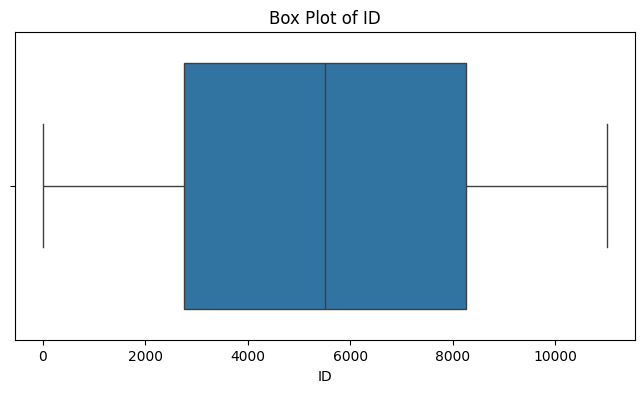

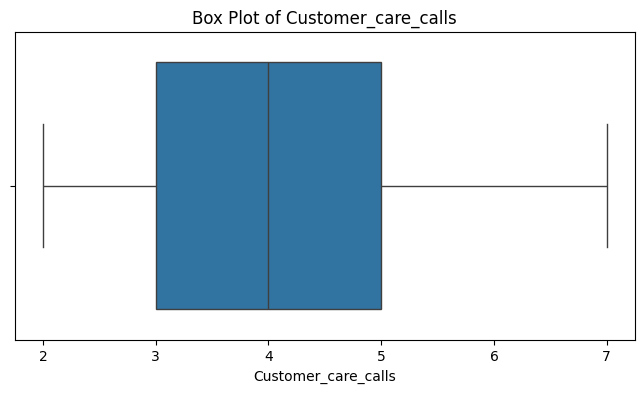

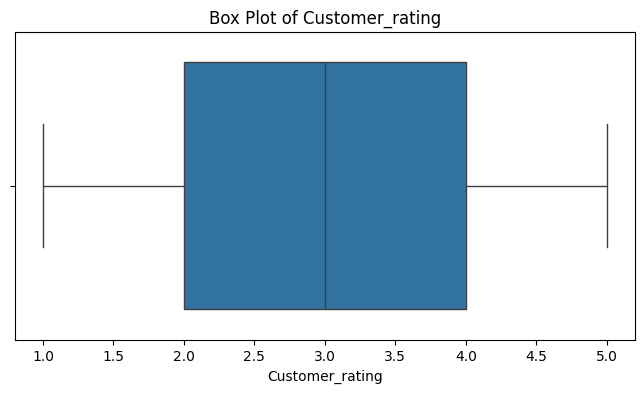

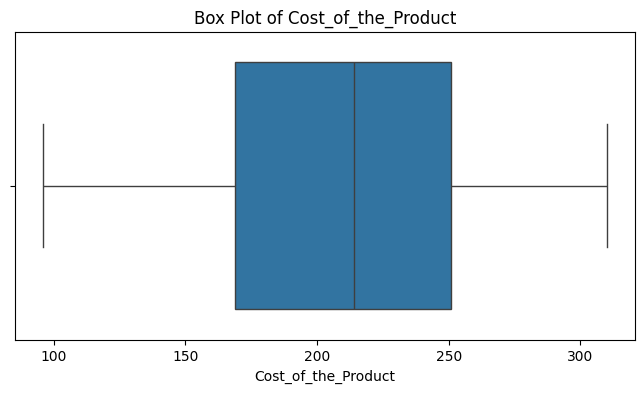

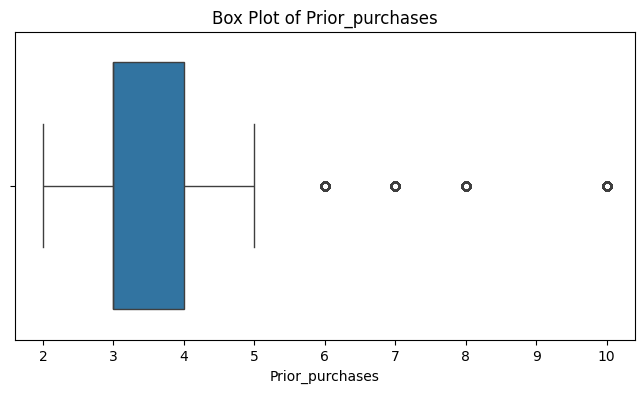

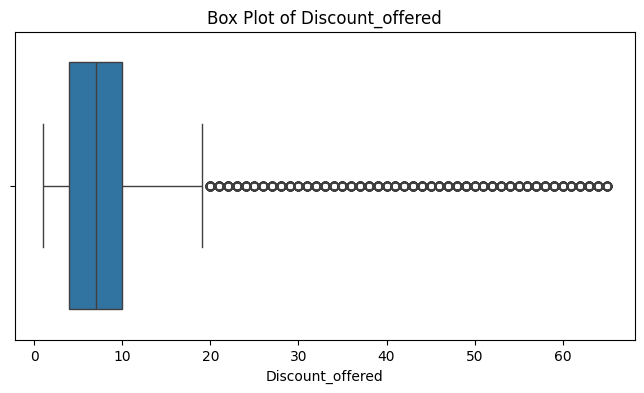

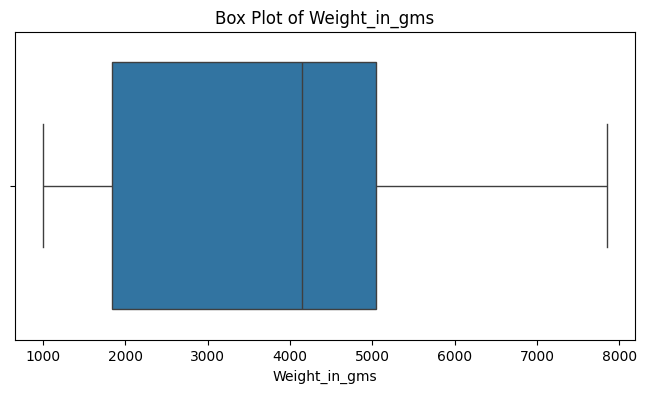

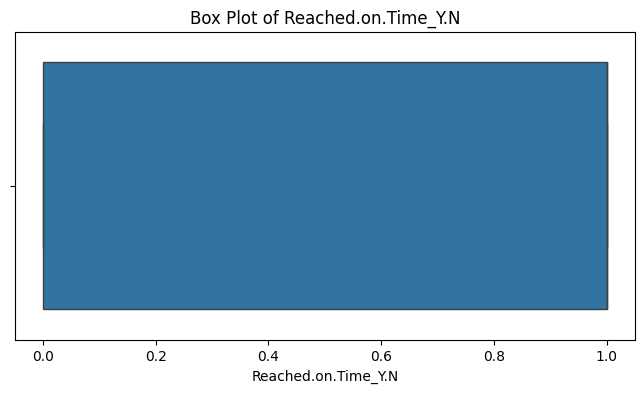

In [14]:
# Create box plots for numerical variables

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

Outlier Analysis Findings

Box plots were used to identify potential outliers in the numerical variables.

Potential extreme observations were observed in `Prior_purchases` and `Discount_offered`. However, these observations may represent genuine customer purchasing behavior and discount values rather than incorrect data.

Therefore, the observations will be retained for further analysis instead of being removed automatically.

The target variable `Reached.on.Time_Y.N` will not be subjected to outlier treatment because it is a binary classification target.

In [15]:
# Identify numerical predictor columns for outlier treatment

outlier_columns = [
    'Customer_care_calls',
    'Customer_rating',
    'Cost_of_the_Product',
    'Prior_purchases',
    'Discount_offered',
    'Weight_in_gms'
]

print("Columns selected for outlier treatment:")
print(outlier_columns)

Columns selected for outlier treatment:
['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']


In [16]:
# Check outlier counts using the IQR method

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[column] < lower_bound) | 
                (df[column] > upper_bound)).sum()
    
    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outliers
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Customer_care_calls,3.0,5.0,2.0,0.00,8.00,0
1,Customer_rating,2.0,4.0,2.0,-1.00,7.00,0
2,Cost_of_the_Product,169.0,251.0,82.0,46.00,374.00,0
3,Prior_purchases,3.0,4.0,1.0,1.50,5.50,1003
4,Discount_offered,4.0,10.0,6.0,-5.00,19.00,2209
5,Weight_in_gms,1839.5,5050.0,3210.5,-2976.25,9865.75,0


# Outlier Treatment Decision

The IQR method identified potential outliers in `Prior_purchases` and `Discount_offered`.

However, these observations are not necessarily data errors. They represent valid values within the e-commerce dataset and may contain useful information for predicting delivery timeliness.

Therefore, the identified observations will not be deleted or capped at this stage.

The remaining numerical variables do not contain IQR-based outliers.

The original values will be retained to avoid losing potentially useful business information.

## Exploratory Data Analysis (EDA)- 

In [17]:
# Count the observations in each target class

target_counts = df['Reached.on.Time_Y.N'].value_counts().sort_index()

print("Target Variable Distribution:")
print(target_counts)

Target Variable Distribution:
Reached.on.Time_Y.N
0    4436
1    6563
Name: count, dtype: int64


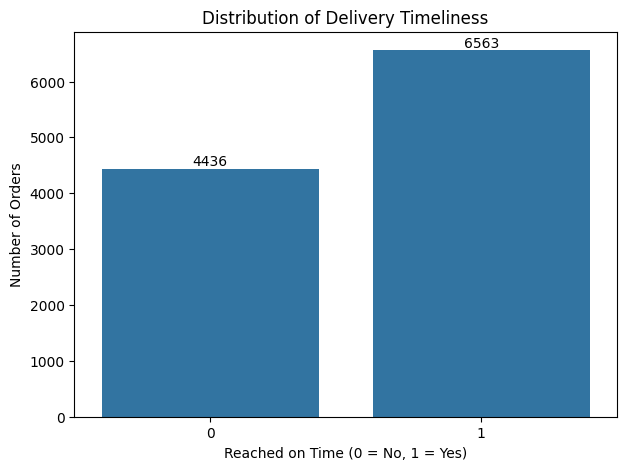

In [18]:
# Visualize target variable distribution

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='Reached.on.Time_Y.N'
)

plt.title('Distribution of Delivery Timeliness')
plt.xlabel('Reached on Time (0 = No, 1 = Yes)')
plt.ylabel('Number of Orders')

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

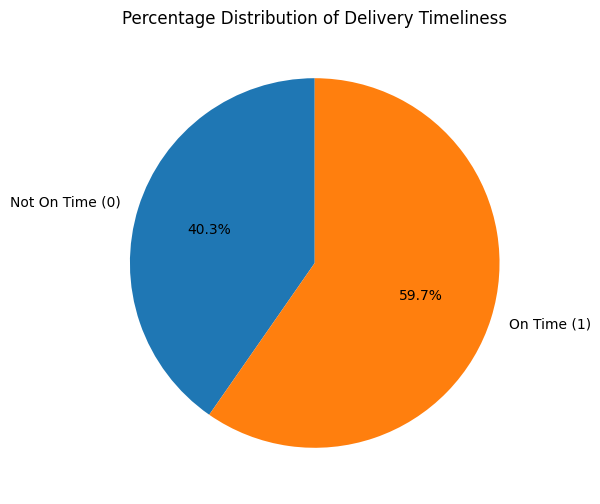

In [19]:
# Visualize percentage distribution

plt.figure(figsize=(6, 6))

plt.pie(
    target_counts,
    labels=['Not On Time (0)', 'On Time (1)'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Percentage Distribution of Delivery Timeliness')

plt.show()

# Target Variable Findings

The target variable `Reached.on.Time_Y.N` contains two classes.

- 4,436 orders (40.3%) did not reach the customer on time.
- 6,563 orders (59.7%) reached the customer on time.

The target classes are not perfectly balanced, with a higher proportion of orders reaching on time.

However, both classes have substantial representation in the dataset. Therefore, no observations will be removed or artificially balanced at this stage.

During model evaluation, accuracy will be considered along with precision, recall, F1-score, and the confusion matrix to obtain a more complete assessment of classification performance.

In [20]:
#Univariate Analysis of Categorical Variables
# Identify categorical columns

categorical_columns = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


In [21]:
# Display unique values for each categorical variable

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Warehouse_block
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

Mode_of_Shipment
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

Product_importance
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

Gender
Gender
F    5545
M    5454
Name: count, dtype: int64


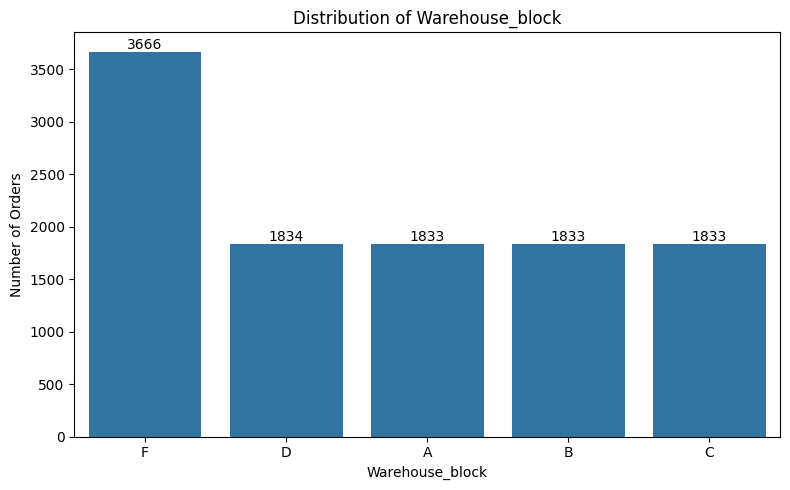

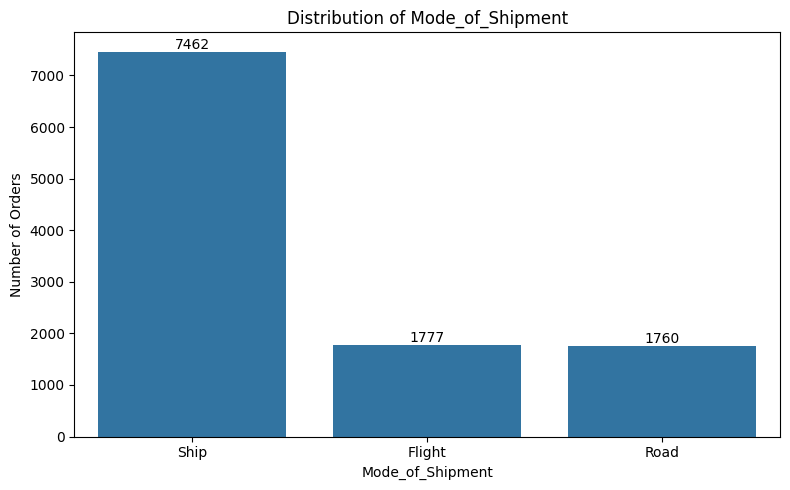

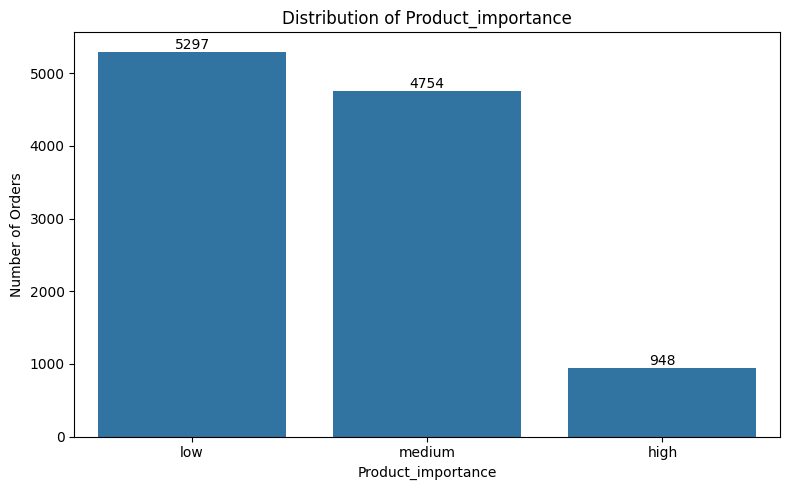

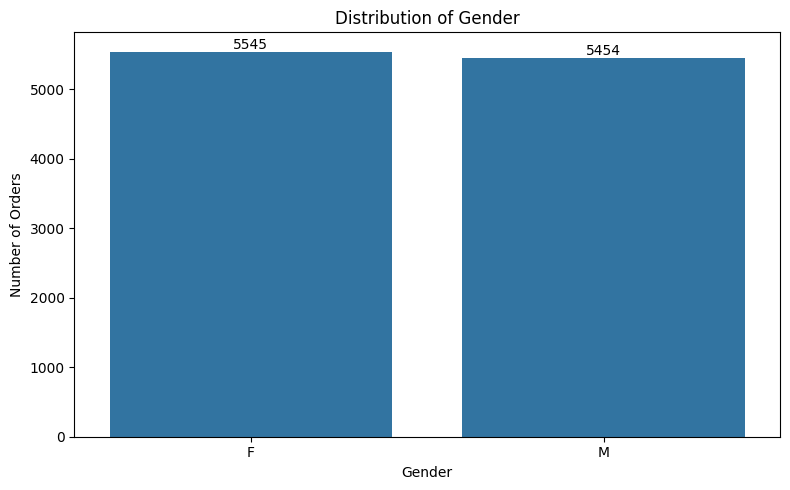

In [22]:
# Plot distributions of categorical variables

for column in categorical_columns:
    
    plt.figure(figsize=(8, 5))
    
    ax = sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )
    
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Number of Orders')
    plt.xticks(rotation=0)
    
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.tight_layout()
    plt.show()

In [23]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Warehouse_block
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

Mode_of_Shipment
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

Product_importance
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

Gender
Gender
F    5545
M    5454
Name: count, dtype: int64


In [24]:
#Univariate Analysis of Numerical Variables
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


In [25]:
# Numerical variable summary

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ID,10999.0,5500.000000,3175.282140,1.0,2750.5,5500.0,8249.5,10999.0
Customer_care_calls,10999.0,4.054459,1.141490,2.0,3.0,4.0,5.0,7.0
Customer_rating,10999.0,2.990545,1.413603,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,10999.0,210.196836,48.063272,96.0,169.0,214.0,251.0,310.0
Prior_purchases,10999.0,3.567597,1.522860,2.0,3.0,3.0,4.0,10.0
Discount_offered,10999.0,13.373216,16.205527,1.0,4.0,7.0,10.0,65.0
Weight_in_gms,10999.0,3634.016729,1635.377251,1001.0,1839.5,4149.0,5050.0,7846.0
Reached.on.Time_Y.N,10999.0,0.596691,0.490584,0.0,0.0,1.0,1.0,1.0


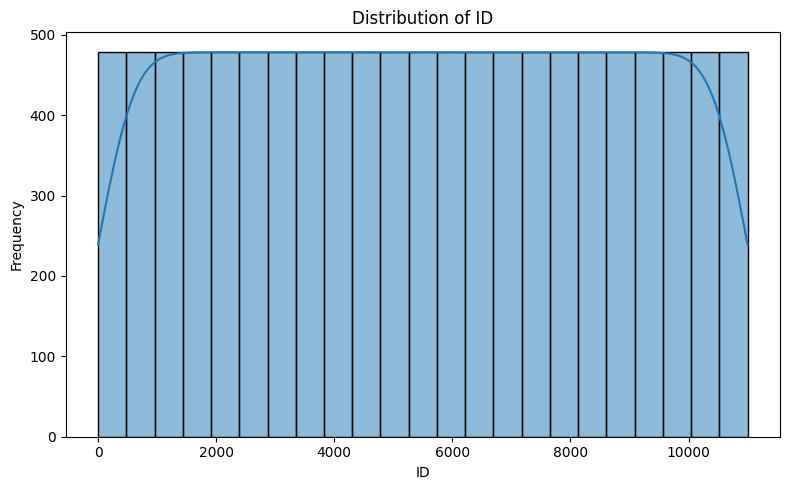

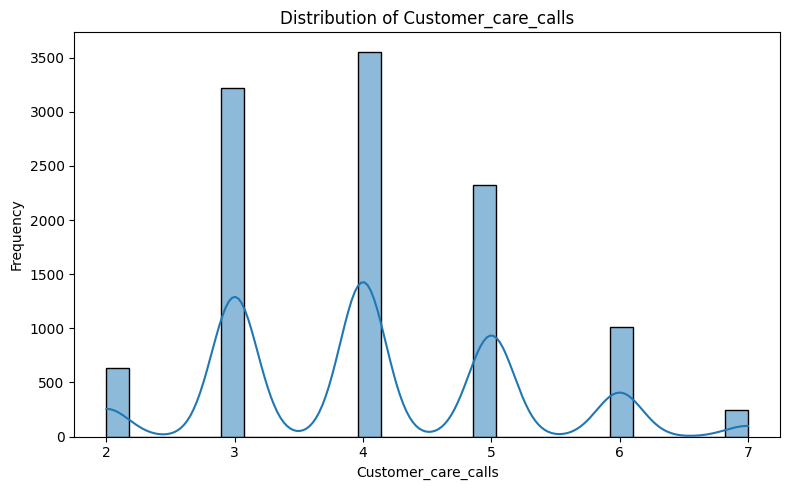

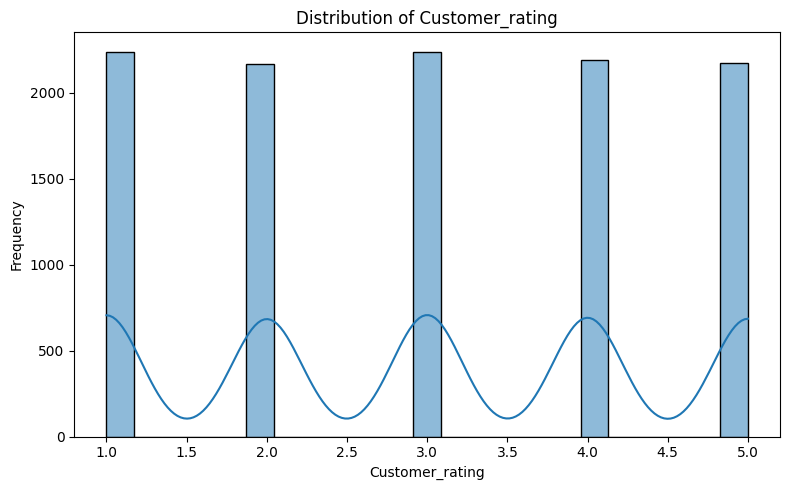

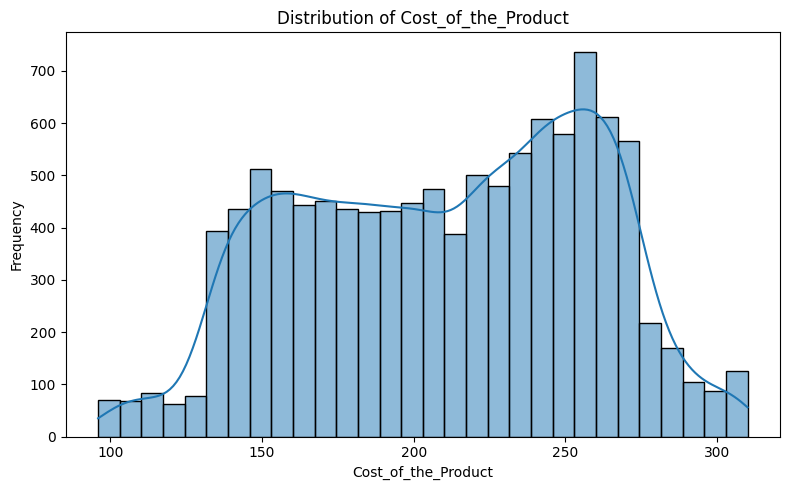

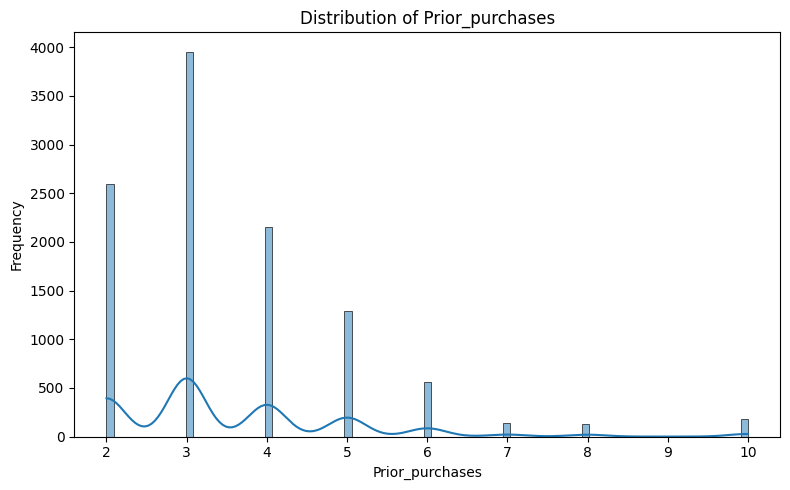

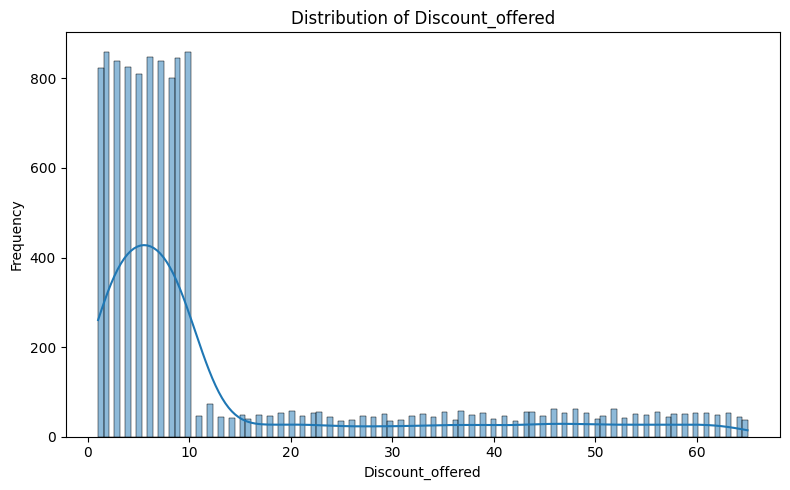

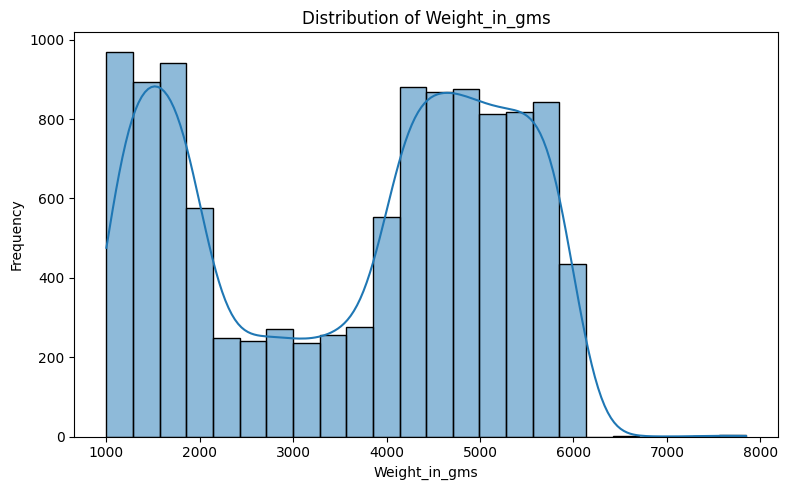

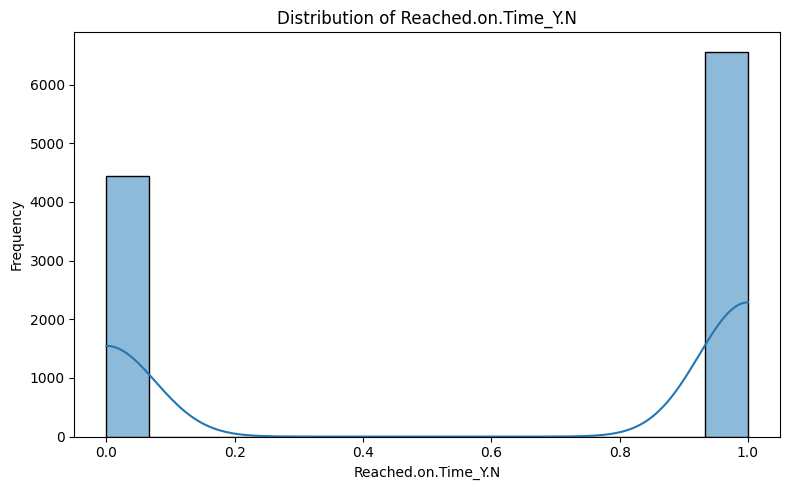

In [26]:
# Plot histograms for numerical variables

for column in numerical_columns:
    
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

In [27]:
#Bivariate Analysis
# Warehouse block vs delivery timeliness
# Calculate delivery percentage by warehouse

warehouse_percentage = pd.crosstab(
    df['Warehouse_block'],
    df['Reached.on.Time_Y.N'],
    normalize='index'
) * 100

warehouse_percentage.columns = ['Not On Time (%)', 'On Time (%)']

warehouse_percentage.round(2)

,Not On Time (%),On Time (%)
Warehouse_block,,
A,41.35,58.65
B,39.77,60.23
C,40.32,59.68
D,40.24,59.76
F,40.15,59.85


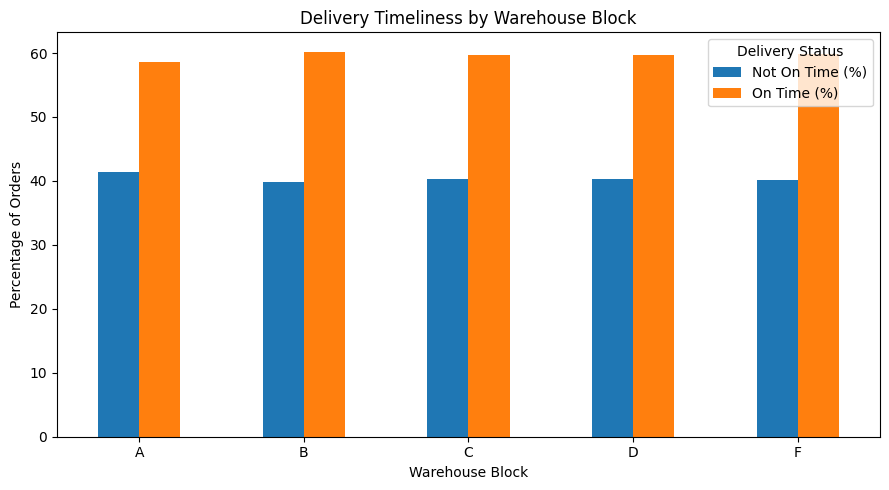

In [28]:
# Visualize warehouse block vs delivery timeliness

warehouse_percentage.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Delivery Timeliness by Warehouse Block')
plt.xlabel('Warehouse Block')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')

plt.tight_layout()
plt.show()

In [29]:
# Shipment mode vs delivery timeliness

shipment_percentage = pd.crosstab(
    df['Mode_of_Shipment'],
    df['Reached.on.Time_Y.N'],
    normalize='index'
) * 100

shipment_percentage.columns = ['Not On Time (%)', 'On Time (%)']

shipment_percentage.round(2)

,Not On Time (%),On Time (%)
Mode_of_Shipment,,
Flight,39.84,60.16
Road,41.19,58.81
Ship,40.24,59.76


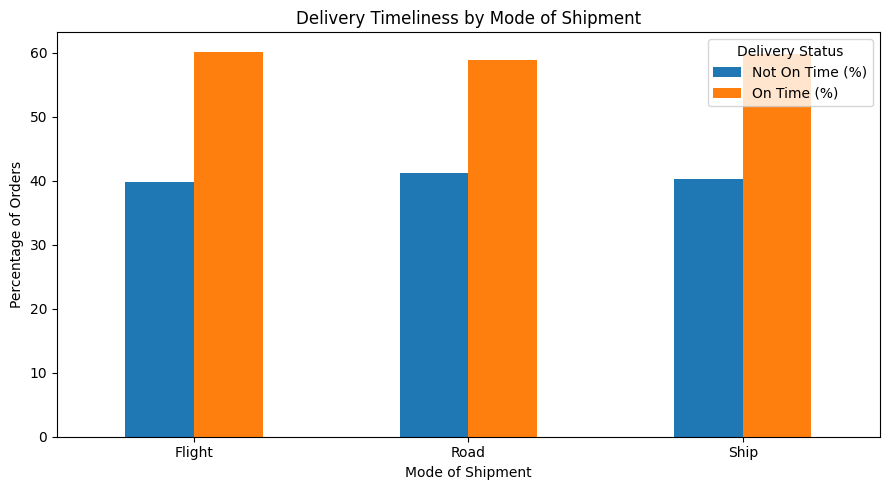

In [30]:
# Visualize shipment mode vs delivery timeliness

shipment_percentage.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Delivery Timeliness by Mode of Shipment')
plt.xlabel('Mode of Shipment')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')

plt.tight_layout()
plt.show()

In [31]:
# Product importance vs delivery timeliness

importance_percentage = pd.crosstab(
    df['Product_importance'],
    df['Reached.on.Time_Y.N'],
    normalize='index'
) * 100

importance_percentage.columns = ['Not On Time (%)', 'On Time (%)']

importance_percentage.round(2)

,Not On Time (%),On Time (%)
Product_importance,,
high,35.02,64.98
low,40.72,59.28
medium,40.95,59.05


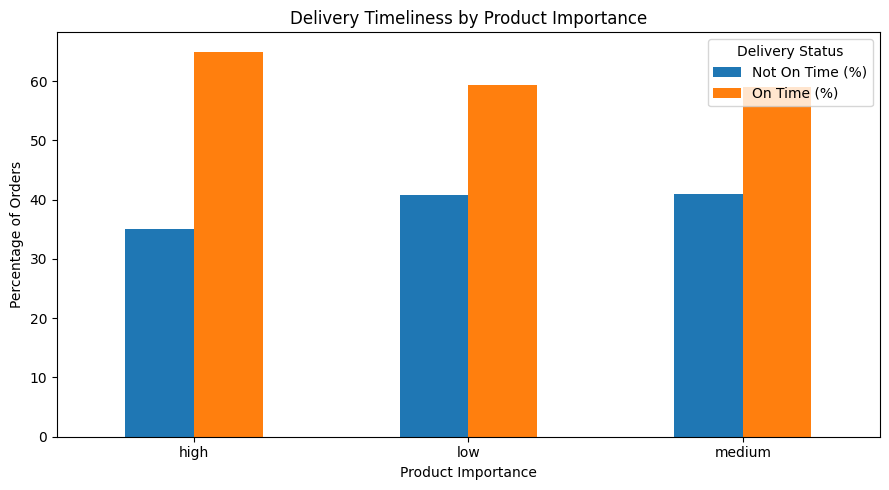

In [32]:
# Visualize product importance vs delivery timeliness

importance_percentage.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Delivery Timeliness by Product Importance')
plt.xlabel('Product Importance')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')

plt.tight_layout()
plt.show()

In [33]:
# Gender vs delivery timeliness

gender_percentage = pd.crosstab(
    df['Gender'],
    df['Reached.on.Time_Y.N'],
    normalize='index'
) * 100

gender_percentage.columns = ['Not On Time (%)', 'On Time (%)']

gender_percentage.round(2)

,Not On Time (%),On Time (%)
Gender,,
F,40.56,59.44
M,40.10,59.90


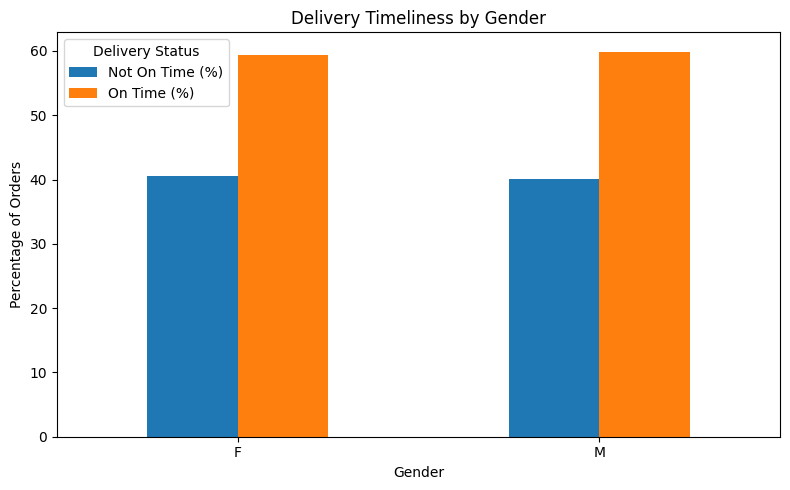

In [34]:
# Visualize gender vs delivery timeliness

gender_percentage.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Delivery Timeliness by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')

plt.tight_layout()
plt.show()

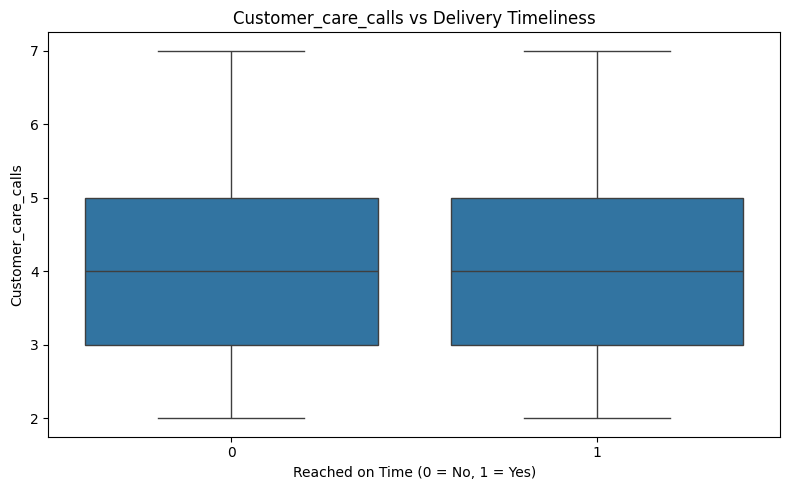

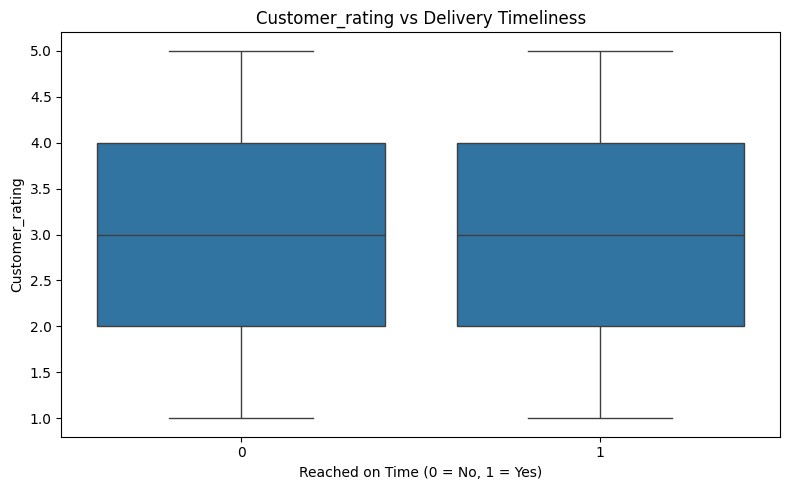

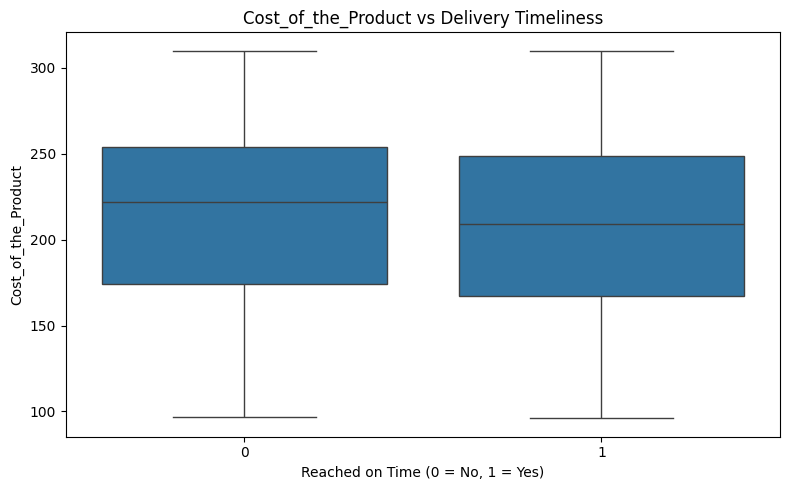

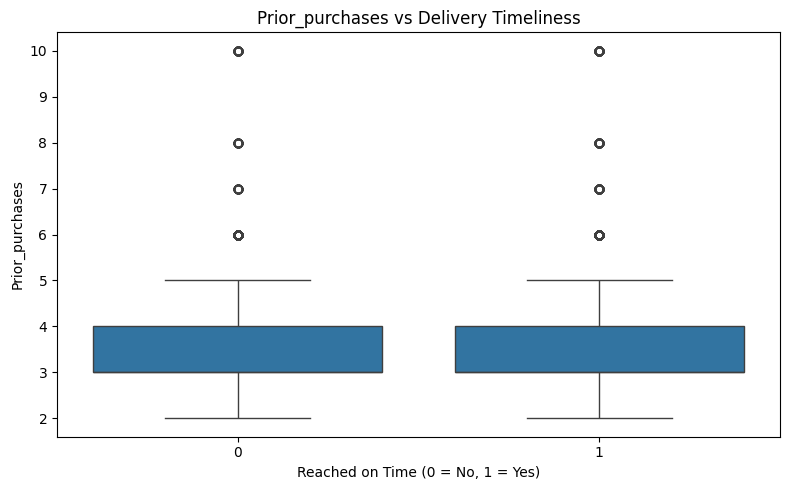

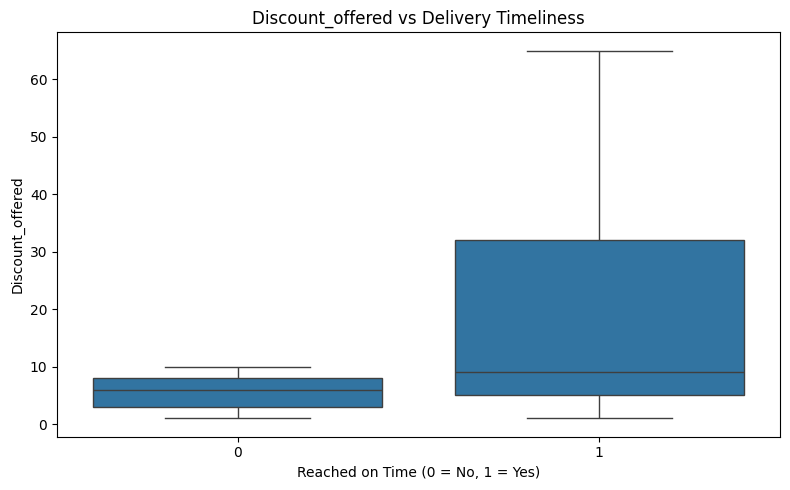

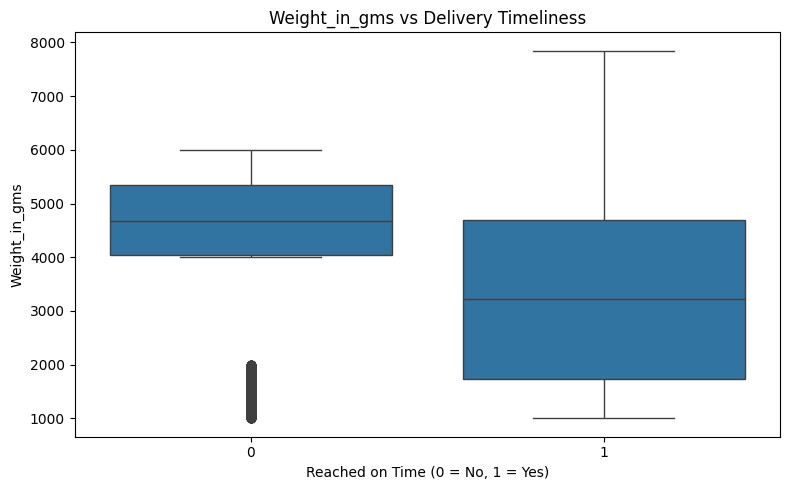

In [35]:
#Numerical Variables vs Delivery Timeliness
# Numerical variables for bivariate analysis

numerical_features = [
    'Customer_care_calls',
    'Customer_rating',
    'Cost_of_the_Product',
    'Prior_purchases',
    'Discount_offered',
    'Weight_in_gms'
]

# Create box plots for numerical features against the target

for column in numerical_features:
    
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x='Reached.on.Time_Y.N',
        y=column
    )
    
    plt.title(f'{column} vs Delivery Timeliness')
    plt.xlabel('Reached on Time (0 = No, 1 = Yes)')
    plt.ylabel(column)
    
    plt.tight_layout()
    plt.show()

In [36]:
# Compare numerical variables by delivery status

numerical_by_target = df.groupby('Reached.on.Time_Y.N')[numerical_features].mean().T

numerical_by_target.columns = ['Not On Time', 'On Time']

numerical_by_target.round(2)

,Not On Time,On Time
Customer_care_calls,4.15,3.99
Customer_rating,2.97,3.01
Cost_of_the_Product,214.50,207.29
Prior_purchases,3.67,3.50
Discount_offered,5.55,18.66
Weight_in_gms,4168.67,3272.64


In [37]:
#Correlation Analysis
# Select numerical variables including the target
correlation_data = df[
    [
        'Customer_care_calls',
        'Customer_rating',
        'Cost_of_the_Product',
        'Prior_purchases',
        'Discount_offered',
        'Weight_in_gms',
        'Reached.on.Time_Y.N'
    ]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Display correlation matrix
correlation_matrix.round(2)

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Customer_care_calls,1.00,0.01,0.32,0.18,-0.13,-0.28,-0.07
Customer_rating,0.01,1.00,0.01,0.01,-0.00,-0.00,0.01
Cost_of_the_Product,0.32,0.01,1.00,0.12,-0.14,-0.13,-0.07
Prior_purchases,0.18,0.01,0.12,1.00,-0.08,-0.17,-0.06
Discount_offered,-0.13,-0.00,-0.14,-0.08,1.00,-0.38,0.40
Weight_in_gms,-0.28,-0.00,-0.13,-0.17,-0.38,1.00,-0.27
Reached.on.Time_Y.N,-0.07,0.01,-0.07,-0.06,0.40,-0.27,1.00


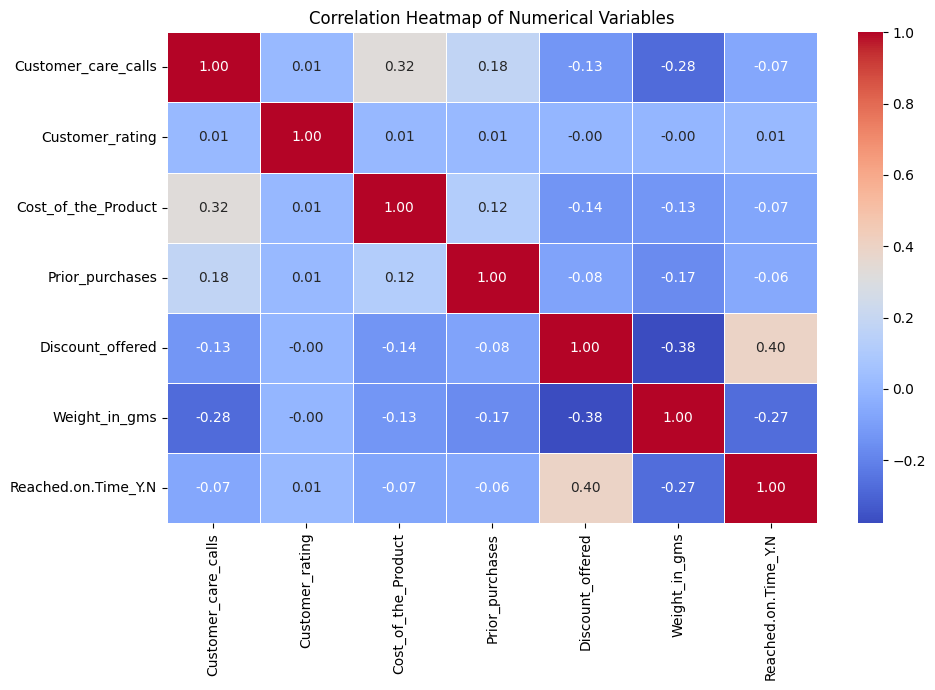

In [38]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

### Key Observations from Correlation Heatmap
Discount_offered has the strongest positive correlation with delivery timeliness (0.40), while Weight_in_gms has a moderate negative correlation (-0.27). The remaining numerical variables show very weak linear relationships with the target.

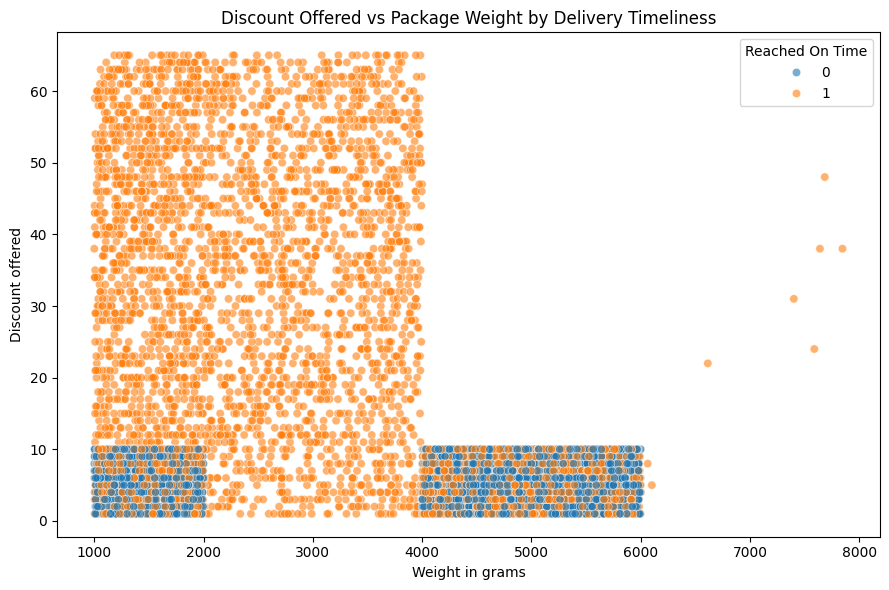

In [39]:
#Multivariate Analysis
# Select numerical variables for multivariate analysis
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Weight_in_gms',
    y='Discount_offered',
    hue='Reached.on.Time_Y.N',
    alpha=0.6
)

plt.title('Discount Offered vs Package Weight by Delivery Timeliness')
plt.xlabel('Weight in grams')
plt.ylabel('Discount offered')
plt.legend(title='Reached On Time')

plt.tight_layout()
plt.show()

## Multivariate Analysis Findings

The scatter plot examines the relationship between `Weight_in_gms` and `Discount_offered` while distinguishing between orders that reached on time and those that did not.

The following observations can be made:

- The observations are widely distributed across different package weights and discount levels.
- Orders that reached on time (`1`) are more widely distributed across the range of `Discount_offered`.
- Orders that did not reach on time (`0`) are more concentrated at lower discount values.
- The plot also shows that higher package weights are generally associated with lower discount values in the dataset.
- The two delivery classes overlap considerably, indicating that `Weight_in_gms` and `Discount_offered` alone do not completely separate on-time and delayed deliveries.

Overall, the visualization supports the earlier correlation analysis, where `Discount_offered` and `Weight_in_gms` showed comparatively stronger relationships with the target. However, multiple features are required to predict delivery timeliness effectively.

## Feature Engineering and preprocessing 

In [40]:
# Separate features and target variable

X = df.drop(columns=['Reached.on.Time_Y.N', 'ID'])
y = df['Reached.on.Time_Y.N']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (10999, 10)
Target shape: (10999,)

Features:
['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms']


In [41]:
# Train test split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8799, 10)
X_test shape: (2200, 10)
y_train shape: (8799,)
y_test shape: (2200,)


In [42]:
#Encoding Categorical Variables
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical features
categorical_features = [
    'Warehouse_block',
    'Mode_of_Shipment',
    'Product_importance',
    'Gender'
]

numerical_features = [
    'Customer_care_calls',
    'Customer_rating',
    'Cost_of_the_Product',
    'Prior_purchases',
    'Discount_offered',
    'Weight_in_gms'
]

# Create the encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)
    ],
    remainder='passthrough'
)

# Fit on training data and transform training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted encoder
X_test_encoded = preprocessor.transform(X_test)

print("Encoded X_train shape:", X_train_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

Encoded X_train shape: (8799, 19)
Encoded X_test shape: (2200, 19)


In [43]:
#Feature scaling 
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Transform test data using the same fitted scaler
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaled X_train shape: (8799, 19)
Scaled X_test shape: (2200, 19)


In [44]:

# Verify the preprocessed data

print("Training features:", X_train_scaled.shape)
print("Testing features:", X_test_scaled.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nNumber of features after preprocessing:", X_train_scaled.shape[1])
print("Number of training observations:", X_train_scaled.shape[0])
print("Number of testing observations:", X_test_scaled.shape[0])

Training features: (8799, 19)
Testing features: (2200, 19)
Training target: (8799,)
Testing target: (2200,)

Number of features after preprocessing: 19
Number of training observations: 8799
Number of testing observations: 2200


In [45]:
#Feature importance Analysis
from sklearn.ensemble import RandomForestClassifier

# Train a preliminary Random Forest model
rf_feature_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_feature_model.fit(X_train_scaled, y_train)

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Create feature importance table
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_feature_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,remainder__Weight_in_gms,0.264023
1,remainder__Discount_offered,0.226677
2,remainder__Cost_of_the_Product,0.167320
3,remainder__Prior_purchases,0.064571
4,remainder__Customer_rating,0.060955
5,remainder__Customer_care_calls,0.057542
6,categorical__Warehouse_block_F,0.015309
7,categorical__Mode_of_Shipment_Ship,0.014400
8,categorical__Product_importance_low,0.013374
9,categorical__Product_importance_medium,0.013026


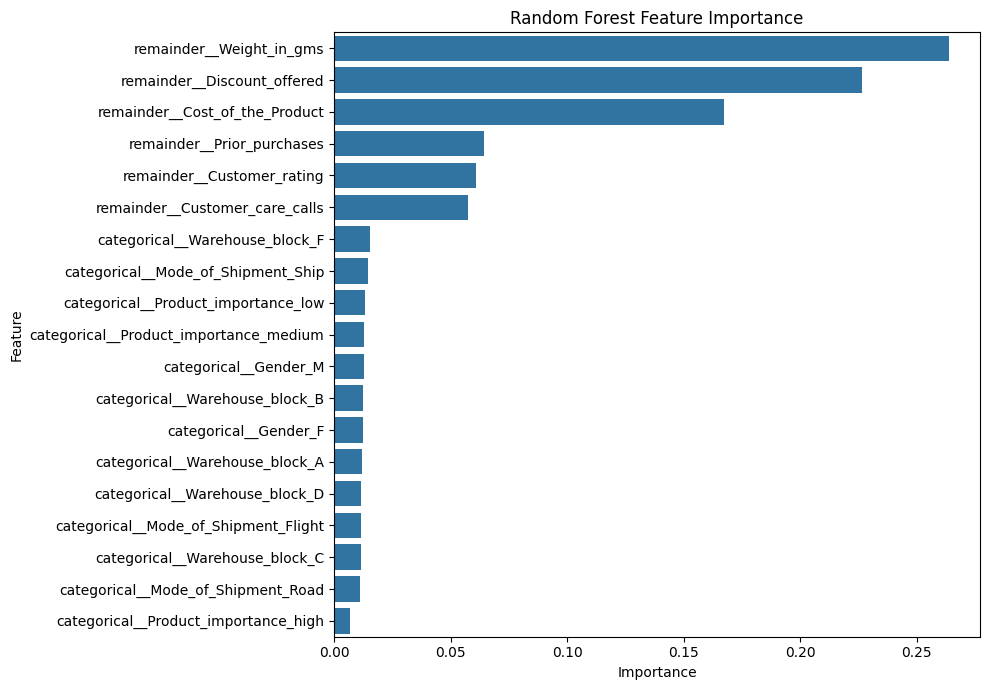

In [46]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model Building 

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Define the five models
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Support Vector Machine': SVC(
        random_state=42
    )
}

# Train all models
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{model_name} trained successfully.")

print("\nAll five models have been trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
KNN trained successfully.
Support Vector Machine trained successfully.

All five models have been trained successfully.


In [48]:
# Generate predictions from all five models

predictions = {}

for model_name, model in models.items():
    predictions[model_name] = model.predict(X_test_scaled)

print("Predictions generated for all five models.")

# Display the number of predictions
for model_name, y_pred in predictions.items():
    print(f"{model_name}: {len(y_pred)} predictions")

Predictions generated for all five models.
Logistic Regression: 2200 predictions
Decision Tree: 2200 predictions
Random Forest: 2200 predictions
KNN: 2200 predictions
Support Vector Machine: 2200 predictions


## Model Evaluation

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

evaluation_results = []

for model_name, model in models.items():
    
    y_pred = predictions[model_name]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    evaluation_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.637727,0.706731,0.671744,0.688793
1,Decision Tree,0.650909,0.700811,0.724296,0.712360
2,Random Forest,0.653636,0.754386,0.622239,0.681970
3,KNN,0.624091,0.697561,0.653465,0.674794
4,Support Vector Machine,0.646818,0.773469,0.577304,0.661143


In [50]:
# classification report
for model_name, y_pred in predictions.items():
    
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Not On Time (0)', 'On Time (1)']
    ))

Logistic Regression
                 precision    recall  f1-score   support

Not On Time (0)       0.55      0.59      0.57       887
    On Time (1)       0.71      0.67      0.69      1313

       accuracy                           0.64      2200
      macro avg       0.63      0.63      0.63      2200
   weighted avg       0.64      0.64      0.64      2200

Decision Tree
                 precision    recall  f1-score   support

Not On Time (0)       0.57      0.54      0.56       887
    On Time (1)       0.70      0.72      0.71      1313

       accuracy                           0.65      2200
      macro avg       0.64      0.63      0.63      2200
   weighted avg       0.65      0.65      0.65      2200

Random Forest
                 precision    recall  f1-score   support

Not On Time (0)       0.56      0.70      0.62       887
    On Time (1)       0.75      0.62      0.68      1313

       accuracy                           0.65      2200
      macro avg       0.66      

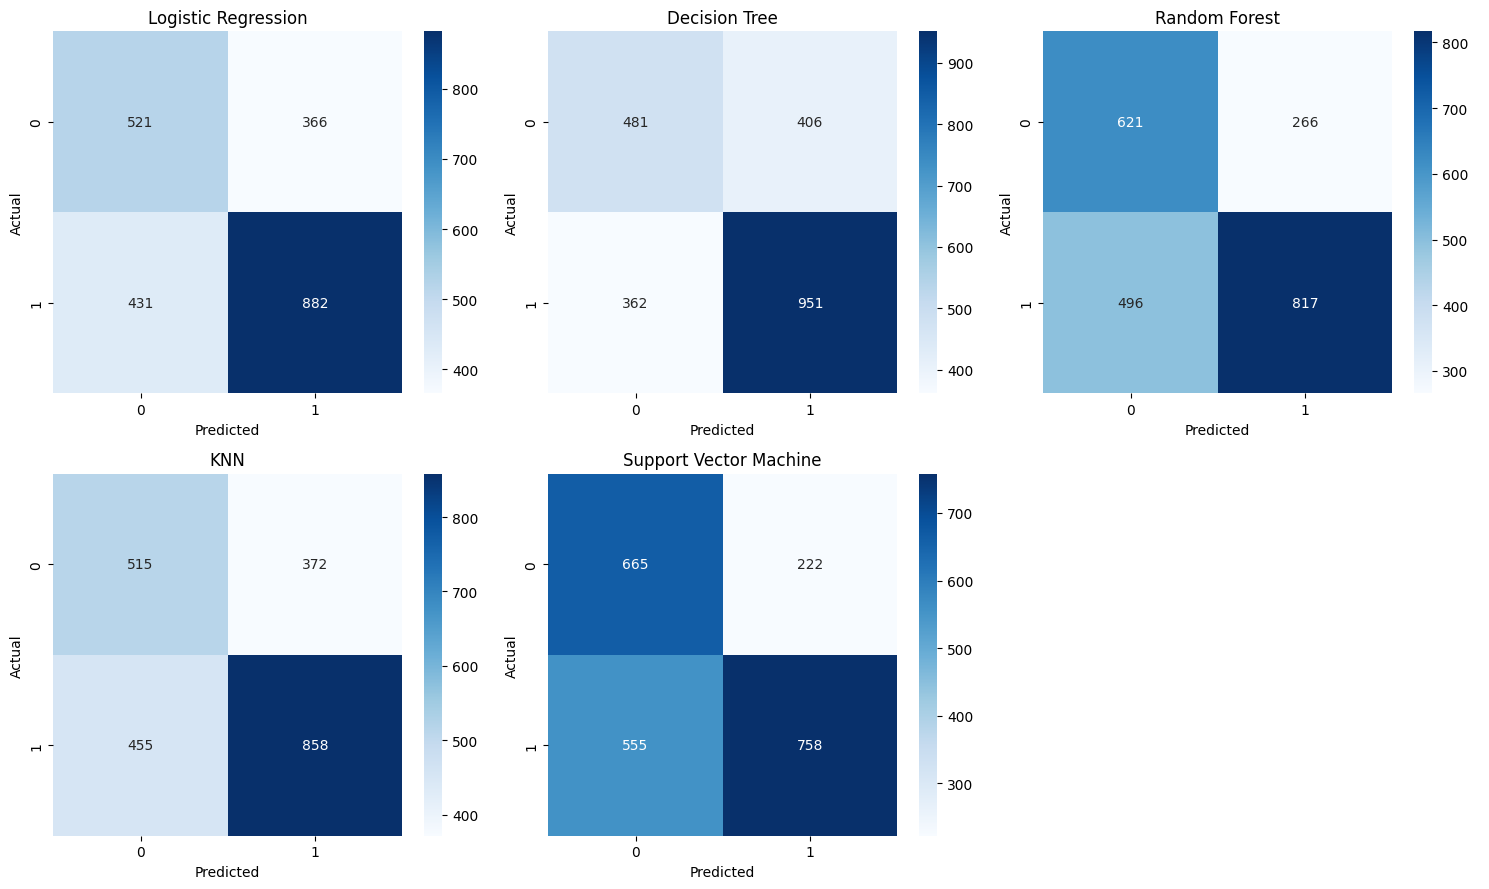

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, (model_name, y_pred) in enumerate(predictions.items()):
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i]
    )
    
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the unused sixth subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## Hyperparameter tunning

In [52]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids for each model

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },

    'Decision Tree': {
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5]
    },

    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },

    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
}

In [ ]:
tuned_models = {}
tuning_results = {}

for model_name, model in models.items():

    print(f"\nTuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train)

    tuned_models[model_name] = grid_search.best_estimator_

    tuning_results[model_name] = {
        'Best Parameters': grid_search.best_params_,
        'Best CV Accuracy': grid_search.best_score_
    }

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

print("\nHyperparameter tuning completed for all five models.")


Tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'C': 0.01, 'solver': 'liblinear'}
Best CV accuracy: 0.6418

Tuning Decision Tree...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV accuracy: 0.6825

Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.6696

Tuning KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Best CV accuracy: 0.6348

Tuning Support Vector Machine...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:
for model_name, result in tuning_results.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Best Parameters:", result['Best Parameters'])
    print("Best CV Accuracy:", round(result['Best CV Accuracy'], 4))
    print()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

tuned_predictions = {}
tuned_evaluation_results = []

for model_name, tuned_model in tuned_models.items():

    # Predict on untouched test data
    y_pred = tuned_model.predict(X_test_scaled)

    tuned_predictions[model_name] = y_pred

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tuned_evaluation_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

tuned_evaluation_df = pd.DataFrame(tuned_evaluation_results)

tuned_evaluation_df.round(4)

## Baseline vs tuned comparison

In [ ]:
# Add model type to both result tables

baseline_comparison = evaluation_df.copy()
baseline_comparison['Version'] = 'Baseline'

tuned_comparison = tuned_evaluation_df.copy()
tuned_comparison['Version'] = 'Tuned'

# Combine baseline and tuned results
model_comparison = pd.concat(
    [baseline_comparison, tuned_comparison],
    ignore_index=True
)

# Arrange columns
model_comparison = model_comparison[
    ['Model', 'Version', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
]

model_comparison.round(4)

##  Analysis of Baseline vs Tuned Models

The comparison between baseline and tuned models shows that hyperparameter tuning does not necessarily improve every evaluation metric simultaneously.

For Logistic Regression, KNN, and Support Vector Machine, both accuracy and F1-score improved after tuning.

For Decision Tree and Random Forest, accuracy increased after tuning, but their F1-scores decreased.

The Decision Tree showed a particularly large increase in precision, from 0.7008 to 0.9691, while its recall decreased from 0.7243 to 0.4783. Consequently, its F1-score decreased from 0.7124 to 0.6405.

Similarly, Random Forest accuracy increased from 0.6536 to 0.6800, while its F1-score decreased from 0.6820 to 0.6664.

This occurs because GridSearchCV was configured to optimize accuracy. Therefore, the selected hyperparameters favored overall accuracy rather than the balance between precision and recall.

These results demonstrate the importance of considering multiple evaluation metrics when assessing classification models.

In [ ]:
# Hyperparameter tuning using F1-score

f1_tuned_models = {}
f1_tuning_results = {}

for model_name, model in models.items():

    print(f"\nTuning {model_name} using F1-score...")

    grid_search_f1 = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid_search_f1.fit(X_train_scaled, y_train)

    f1_tuned_models[model_name] = grid_search_f1.best_estimator_

    f1_tuning_results[model_name] = {
        'Best Parameters': grid_search_f1.best_params_,
        'Best CV F1-Score': grid_search_f1.best_score_
    }

    print(f"Best parameters: {grid_search_f1.best_params_}")
    print(f"Best CV F1-Score: {grid_search_f1.best_score_:.4f}")

print("\nF1-score based hyperparameter tuning completed.")

In [ ]:
for model_name, result in f1_tuning_results.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Best Parameters:", result['Best Parameters'])
    print("Best CV F1-Score:", round(result['Best CV F1-Score'], 4))
    print()

In [ ]:
f1_tuned_predictions = {}
f1_evaluation_results = []

for model_name, tuned_model in f1_tuned_models.items():

    y_pred = tuned_model.predict(X_test_scaled)

    f1_tuned_predictions[model_name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    f1_evaluation_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

f1_evaluation_df = pd.DataFrame(f1_evaluation_results)

f1_evaluation_df.round(4)

In [ ]:
# Model performance comparison 
# Create comparison tables for all three stages

baseline_comparison = evaluation_df.copy()
baseline_comparison['Tuning'] = 'Baseline'

accuracy_comparison = tuned_evaluation_df.copy()
accuracy_comparison['Tuning'] = 'Accuracy Tuned'

f1_comparison = f1_evaluation_df.copy()
f1_comparison['Tuning'] = 'F1 Tuned'

# Combine all results
model_comparison = pd.concat(
    [
        baseline_comparison,
        accuracy_comparison,
        f1_comparison
    ],
    ignore_index=True
)

# Arrange columns
model_comparison = model_comparison[
    ['Model', 'Tuning', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
]

# Display rounded results
model_comparison.round(4)

##  Final Model Selection

After comparing the baseline, accuracy-tuned, and F1-score-tuned models, the Baseline Decision Tree is selected as the final model.

The Baseline Decision Tree achieved an accuracy of 0.6509, precision of 0.7008, recall of 0.7243, and F1-score of 0.7124.

The model achieved the highest F1-score among the evaluated models. Its recall of 0.7243 also indicates that it correctly identifies a relatively high proportion of products that reached on time.

The previously generated confusion matrix and classification report are used to support the final evaluation of the selected model.

In [ ]:
# Performance metrics of the final Decision Tree model

final_metrics = {
    'Accuracy': 0.6509,
    'Precision': 0.7008,
    'Recall': 0.7243,
    'F1-Score': 0.7124
}

plt.figure(figsize=(8, 5))

plt.bar(
    final_metrics.keys(),
    final_metrics.values()
)

plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Final Model Performance - Decision Tree')

for i, value in enumerate(final_metrics.values()):
    plt.text(i, value + 0.02, f'{value:.4f}', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save the final Decision Tree model
joblib.dump(models['Decision Tree'], 'decision_tree_model.pkl')

# Save the fitted preprocessing objects
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and preprocessing files saved successfully.")

In [ ]:
# Show one real row from the dataset for testing Streamlit

test_row = df.iloc[0]

test_row